# Joint Diffusion training

In [1]:
import os
import sys
import time
from pprint import pprint
sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data
from diffusionsim import climsim_utils as cut
from diffusionsim.trainers import DiffusionTrainer, ClimsimTrainer


device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
from pprint import pprint
REF_BATCH_SIZE = 128
#exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
dataset_type = "climsim_train"
climsim_training = True
in_notebook = True
diffusers_available = False
def setup_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dconfig = tru.my_dconfig(data_vars, in_notebook, dataset_type, batch_size)
    dconfig.train_test_split = [0.01, 0.002]
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 1e-4, 1e-4]
    #distloss_weights = [1.0, 1.0, 2.0, 5.0]
    diffloss_weights = [1.0, 1.0, 1.0, 1.0]
    target_variables_distloss = [68, 60, 73, 82]
    num_gaussians = [3, 2, 3, 2]
    unet_channel_dims = []
    unet_down_block_types = []

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': 1.0, 'distribution': 0, 'diffusion': diffloss_weights[i]}
        tconfig.distloss_var_ind = target_variables_distloss[i]
        tconfig.num_gaussians = num_gaussians[i]

        tconfig.max_T_sample = 51
        tconfig.phases = ['train', 'eval']

        unet = tru.UNetParams()
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels

        scheduler = tru.SchedulerParams()
        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        if(climsim_training):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_num_layers = len(mconfig.bl_hidden_dims)
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)



### Playground for testing scripts

#### Diff training

In [3]:
exp_id = "diffusion_hp_search"
run_id = "trial_1"
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"

num_models = 3
base_dir = os.path.join(exp_dir, exp_id)

In [4]:
tconfigs, mconfigs, dconfig = setup_run(num_models, exp_id, run_id,
              data_vars='v1', batch_size=128)

dconfig.train_test_split = [0.001]

In [5]:
trainer = DiffusionTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [7]:
trainer.train(num_epochs=1)

Getting ready to train 3 model(s) for 1 epochs
Training for 1 epochs


{"event": "epoch start", "time": 1743658643.1590219, "pid": 1742437, "epoch": 0}
{"event": "batch-0 start", "time": 1743658645.2592452, "pid": 1742437, "batch": 0}
{"event": "run-batch start", "time": 1743658645.259493, "pid": 1742437}
{"event": "run-batch end", "time": 1743658713.6404977, "pid": 1742437, "duration": 68.38098978996277, "trial_1a": 1.1157360076904297, "trial_1b": 1.1225813627243042, "trial_1c": 1.1136373281478882}
{"event": "batch-0 end", "time": 1743658713.6414442, "pid": 1742437, "batch": 0, "duration": 68.38219618797302}


Currently at epoch 0, step 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1a-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1b-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1c-ckpt.pt
Finished training 3 model(s) for 1 epochs.


{"event": "epoch end", "time": 1743658714.4111528, "pid": 1742437, "epoch": 0, "duration": 71.252121925354, "epoch_loss": {"trial_1a": [1.1157360076904297], "trial_1b": [1.1225813627243042], "trial_1c": [1.1136373281478882]}}


In [18]:
print(trainer.dataloaders['train'].dataset.data.sizes)
trainer.dataloaders['train'].dataset.bgen._batch_selectors.selectors


Frozen({'time': 210, 'lev': 60, 'ncol': 384})


{0: [{'time': slice(0, 128, None),
   'lev': slice(0, 60, None),
   'ncol': slice(0, 384, None)}]}

In [ ]:
trainer.noise_timesteps['trial_1a'].tensor

tensor([29, 25, 27, 28, 27, 25, 31, 20, 19, 26, 28, 27, 28, 31, 23, 19, 17, 22,
        31, 21, 22, 25, 26, 23, 23, 24, 29, 22, 21, 19, 34, 18, 27, 38, 20, 24,
        17, 33, 27, 21, 27, 26, 25, 28, 30, 22, 21, 29, 29, 25, 21])

In [9]:
trainer.finish_training(True, num_epochs=2)

AttributeError: 'dict' object has no attribute 'cpu'

In [5]:
dataloaders, indices = tru.load_dataloaders(dconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [6]:
dataloader_dict = dict(train=dataloaders[0])
loss_fn = torch.nn.MSELoss()

In [6]:
#mconfig.unet.block_out_channels = (128, 256, 512) #if dconfig.data_vars == "v1" else (256, 512, 1024)
#model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, exp_id, exp_dir)

In [54]:
bind = ds.bgen._batch_selectors.selectors
bind[5]

[{'time': slice(2560, 3072, None),
  'lev': slice(0, 60, None),
  'ncol': slice(0, 384, None)}]

#### Train Clim

In [5]:
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "testing_just_mse"

In [7]:
exp_dir= "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "DiffLossTraining"
run_id = "testing_diffloss_0"
base_dir = os.path.join(exp_dir, exp_id)

In [5]:
tconfigs, mconfigs, dconfig = setup_run(4, exp_id, run_id, 'v1', 128)
dconfig.train_test_split = [0.0015, 0.001]

pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.0015, 0.001],
           dataloader_params=TrainLoaderParams(batch_size=49152,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [6]:
trainer = ClimsimTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0)
trainer.dataloaders['train'], len(trainer.dataloaders['train'])

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


(<torch.utils.data.dataloader.DataLoader at 0x15520daca540>, 2)

In [7]:
trainer.training_configs#.state_dict()

{'testing_distloss_a': TrainingConfig(exp_id='JointTraining', run_id='testing_distloss_a', num_epochs=5, phases=['train'], distributed_training=False, optimizer='adam', betas=(0.9, 0.999), lr_scheduler=None, learning_rate=0.0001, loss_weights={'mse': 1.0, 'distribution': 1.0, 'diffusion': 0.0}, clip_gradients=True, max_T_sample=51, save_best_epoch=True, batch_logging_interval=32, batch_checkpoint_interval=50, log_gradients=False, push_to_hub=False, diffusion_loss_noise_level=10, num_gaussians=2, num_distloss_samples=4, distloss_bs=3072, distloss_var_ind=68),
 'testing_distloss_b': TrainingConfig(exp_id='JointTraining', run_id='testing_distloss_b', num_epochs=5, phases=['train'], distributed_training=False, optimizer='adam', betas=(0.9, 0.999), lr_scheduler=None, learning_rate=0.0001, loss_weights={'mse': 1.0, 'distribution': 1.0, 'diffusion': 0.0}, clip_gradients=True, max_T_sample=51, save_best_epoch=True, batch_logging_interval=32, batch_checkpoint_interval=50, log_gradients=False, p

In [8]:
trainer.train(num_epochs=1, log=True)

Getting ready to train 4 model(s) for 1 epochs
Epoch 1/1
__________


{"event": "epoch-0 start", "time": 1744077811.8576164, "pid": 2475942}


Currently at epoch 0, step 0/2


{"event": "run-batch start", "time": 1744077814.7816627, "pid": 2475942}
{"event": "run-batch end", "time": 1744077815.7381513, "pid": 2475942, "duration": 0.9564797878265381, "loss": 141.38180541992188}
{"event": "run-batch end", "time": 1744077816.0537167, "pid": 2475942, "duration": 1.272050380706787, "loss": 152.74781799316406}
{"event": "run-batch end", "time": 1744077816.3833926, "pid": 2475942, "duration": 1.6017262935638428, "loss": 142.4958038330078}
{"event": "run-batch end", "time": 1744077816.7183433, "pid": 2475942, "duration": 1.9366779327392578, "loss": 216.10232543945312}
{"event": "run-batch start", "time": 1744077821.2480376, "pid": 2475942}
{"event": "run-batch end", "time": 1744077821.6032495, "pid": 2475942, "duration": 0.3552076816558838, "loss": 465.1177062988281}
{"event": "run-batch end", "time": 1744077821.8512018, "pid": 2475942, "duration": 0.6031608581542969, "loss": 528.8964233398438}
{"event": "run-batch end", "time": 1744077822.108144, "pid": 2475942, "d




avg mse loss for epoch 0, run_id testing_distloss_a: 4.620398998260498
avg total loss for epoch 0, run_id testing_distloss_a: 141.38180541992188
saving new checkpoint at epoch 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/JointTraining/checkpoints/testing_distloss_a-ckpt.pt
avg distribution loss for epoch 0, run_id testing_distloss_a: 136.76140970271769
avg distribution loss for epoch 0, run_id testing_distloss_a: 136.76140970271769
avg distribution loss for epoch 0, run_id testing_distloss_a: 136.76140970271769
avg distribution loss for epoch 0, run_id testing_distloss_a: 136.76140970271769
avg mse loss for epoch 0, run_id testing_distloss_b: 4.6165971755981445
avg total loss for epoch 0, run_id testing_distloss_b: 152.74781799316406
saving new checkpoint at epoch 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/JointTraining/checkpoints/testing_distloss_b-ckpt.pt
avg distribution loss for epoch 0, run_id testing_distloss_b: 148.13122720234637
avg distribution loss f

{"event": "run-batch end", "time": 1744077822.3569446, "pid": 2475942, "duration": 1.1089038848876953, "loss": 334.42669677734375}
{"event": "epoch-0 end", "time": 1744077822.3574686, "pid": 2475942}


In [62]:
log = trainer.finish_training(log=True, num_epochs=100)

Finished training 100 epochs.


In [12]:
with open(os.path.join(trainer.dirs['log_dir'], 'testing_distloss_a.json'), 'r') as f:
    log_data = json.load(f)

log_data.keys()


dict_keys(['training_config', 'model_config', 'data_config', 'best_loss', 'losses', 'train_loss', 'mse_loss', 'total_loss', 'distribution_loss'])

In [16]:
x, y = trainer.dataloaders['train'].dataset[0]

In [18]:
batch_losses = trainer._run_batch(x.to(device), y.to(device), 'train')

{"event": "run-batch start", "time": 1744078624.836099, "pid": 2475942}
{"event": "run-batch end", "time": 1744078625.155089, "pid": 2475942, "duration": 0.3189873695373535, "loss": 137.5587615966797}
{"event": "run-batch end", "time": 1744078625.459333, "pid": 2475942, "duration": 0.6232316493988037, "loss": 136.02198791503906}
{"event": "run-batch end", "time": 1744078625.790205, "pid": 2475942, "duration": 0.954103946685791, "loss": 149.74610900878906}
{"event": "run-batch end", "time": 1744078626.0908024, "pid": 2475942, "duration": 1.2547011375427246, "loss": 135.84593200683594}


In [23]:
from collections import defaultdict
epoch_losses = defaultdict(dict)


In [38]:
epoch_losses = trainer.log_step(epoch_losses, batch_losses, 32, "train")

In [41]:
batch_losses

{'testing_distloss_a': {'mse': 4.613554000854492,
  'distribution': 132.94520659640085,
  'total': 137.5587615966797},
 'testing_distloss_b': {'mse': 4.6122355461120605,
  'distribution': 131.4097549569163,
  'total': 136.02198791503906},
 'testing_distloss_c': {'mse': 4.62640380859375,
  'distribution': 145.11971086524653,
  'total': 149.74610900878906},
 'testing_distloss_d': {'mse': 4.590487957000732,
  'distribution': 131.25544573709482,
  'total': 135.84593200683594}}

In [42]:
trainer.tracked_losses

['mse',
 'total',
 'distribution',
 'distribution',
 'distribution',
 'distribution']

In [40]:
epoch_losses

defaultdict(dict,
            {'testing_distloss_a': {'mse': [4.613554000854492,
               4.613554000854492,
               4.613554000854492,
               4.613554000854492],
              'total': [137.5587615966797,
               137.5587615966797,
               137.5587615966797,
               137.5587615966797],
              'distribution': [132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085,
               132.94520659640085]},
             'testing_distloss_b': {'mse': [4.6122355461120605,
               4.6122355461120605,
               4.6122355461120605,
               4.6122355461120605],
              'total': [136

In [14]:
trainer.losses

{'testing_distloss_a': {'train': [],
  'mse': [4.620398998260498],
  'total': [141.38180541992188],
  'distribution': [136.76140970271769,
   136.76140970271769,
   136.76140970271769,
   136.76140970271769]},
 'testing_distloss_b': {'train': [],
  'mse': [4.6165971755981445],
  'total': [152.74781799316406],
  'distribution': [148.13122720234637,
   148.13122720234637,
   148.13122720234637,
   148.13122720234637]},
 'testing_distloss_c': {'train': [],
  'mse': [4.647116184234619],
  'total': [142.4958038330078],
  'distribution': [137.84869344469078,
   137.84869344469078,
   137.84869344469078,
   137.84869344469078]},
 'testing_distloss_d': {'train': [],
  'mse': [4.618308067321777],
  'total': [216.10232543945312],
  'distribution': [211.48401037725512,
   211.48401037725512,
   211.48401037725512,
   211.48401037725512]}}

### Validating Data Loading via Buckets (deprecated)

In [8]:
dconfig.dataset_type = "ClimsimImageDataset"
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.05, 0.02]
dconfig.dataloader_params.batch_size = 256
dconfig.dataloader_params

TrainLoaderParams(batch_size=256, shuffle=False, num_workers=0, prefetch_factor=None, persistent_workers=False, multiprocessing_context=None, pin_memory=True)

In [9]:
dsi, dso = cut.load_raw_dataset(dconfig)

In [23]:
datasets, indices = data.train_test_split(dsi, dso, dconfig.train_test_split)
(dsi_train, dso_train), (dsi_test, dso_test) = datasets

In [24]:
from dask.diagnostics import ProgressBar

In [33]:
with ProgressBar():
    dsi_train.load()
    dso_train.load()

[########################################] | 100% Completed | 179.45 s


In [37]:
train_ds = data.ClimsimImageDataset(dsi_train, dso_train, dconfig, log=False)
test_ds =  data.ClimsimImageDataset(dsi_test, dso_test, dconfig, log=False)

## Training no Dist Loss

In [219]:
exp_dir= "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "JointTraining"
run_id = "trial1_just_mse"
base_dir = os.path.join(exp_dir, exp_id)

In [272]:
tconfigs, mconfigs, dconfig = setup_run(4, exp_id, run_id, 'v1', 128)
tconfig = tconfigs[0]
mconfig = mconfigs[0]
dconfig.train_test_split = [0.01, 0.002]
pprint(dconfig)

use_distribution_loss = False
use_diffusion_loss = False

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=49152,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [273]:
dsi, dso, dutils = cut.load_raw_dataset(dconfig, return_dutils=True)


In [12]:
print(dsi.sizes['time'] * dconfig.train_test_split[0], dsi.sizes['time'] * dconfig.train_test_split[1])
#train_indices = np.random.randint(50_000, 100_000, size=2048)
train_dsi, train_dso = dsi.isel(time=slice(0, 2048)), dso.isel(time=slice(0, 2048))

#test_indices = np.random.randint(150_000, 175_000, size=512)
test_dsi, test_dso = dsi.isel(time=slice(2048, 2560)), dso.isel(time=slice(2048, 2560))

train_ds = data.ClimsimDataset(train_dsi.unify_chunks(), train_dso.unify_chunks(), dutils, dconfig, log=True)
test_ds = data.ClimsimDataset(test_dsi.unify_chunks(), test_dso.unify_chunks(), dutils, dconfig, log=True)



2102.38 420.476


In [13]:
item = train_ds[0]

{"event": "get-batch start", "time": 1743144594.0643258, "pid": 161981, "batch_idx": 0}
{"event": "get-batch end", "time": 1743144597.7208855, "pid": 161981, "batch_idx": 0, "duration": 3.656552791595459}


In [14]:
import dataclasses
params = dataclasses.asdict(dconfig.dataloader_params)
params['batch_size'] = 1
dataloaders = [
    torch.utils.data.DataLoader(train_ds, collate_fn=data.collate_test_fn, **params),
    torch.utils.data.DataLoader(test_ds, collate_fn=data.collate_test_fn, **params)
]

In [156]:
mconfig.bl_load_model_name = None
model = tru.build_baseline_model(mconfig).to(device)
loss_fn = torch.nn.MSELoss()
optimizer = tru.create_optimizer(model, tconfig)
rank = 0
model

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
)

In [157]:
model2 = tru.build_baseline_model(mconfig).to(device)
optimizer2 = tru.create_optimizer(model2, tconfig)

In [24]:
x,y = item
loss_fn(model(x.to(device)), y.to(device))

tensor(4.6360, device='cuda:0', grad_fn=<MseLossBackward0>)

In [35]:
tconfig.loss_weights

{'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}

In [36]:
base_dir

'/mnt/home/ssa2206/Climsim/experiments/JointTraining'

In [179]:
def distribution_loss(y_hat, y, tconfig):
    GMM = GaussianMixture(n_components=tconfig.num_gaussians)
    GMM.fit(y[:,tconfig.distloss_var_ind].detach().cpu().numpy().reshape(-1, 1))
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=y_hat.device)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (technically (n_c, d,d) but flattened), 
    epsilon = 1e-7 # Ensure pi and var are positive and non-zero for stability
    pi = torch.clamp(pi, min=epsilon)
    var = torch.clamp(var, min=epsilon)
    
    with torch.no_grad():
        h = 2 * torch.max(var).item()

    bs, n_samples = tconfig.distloss_bs, tconfig.num_distloss_samples
    batch_num = y_hat.shape[0] // bs
    ix, jx = torch.randint(0, batch_num, (n_samples,)), torch.randint(0, batch_num, (n_samples,))
    mask = ix == jx
    while mask.any():
        ix[mask] = torch.randint(0, batch_num, (mask.sum(),))
        jx[mask] = torch.randint(0, batch_num, (mask.sum(),))
        mask = ix == jx
    loss = 0
    for i,j in zip(ix, jx):
        y1 = y_hat[i*bs : (i+1)*bs, tconfig.distloss_var_ind]
        y2 = y_hat[j*bs : (j+1)*bs, tconfig.distloss_var_ind]
        loss += u_q(y1, y2, mu, var, pi, h).mean()
    return(loss / n_samples)

In [214]:
loss_fn = torch.nn.MSELoss()
def run_batch(model, x, y, optimizer, loss_weights, loss_dict, use_dist=False):
    x, y = x.to(device), y.to(device)
    y_hat = model(x)
    mse_loss = loss_fn(y_hat, y)
    dist_loss = distribution_loss(y, y_hat)
    if(use_dist):
        total_loss = loss_weights['mse'] * mse_loss + loss_weights['distribution'] * dist_loss
    else:
        total_loss = loss_weights['mse'] * mse_loss
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    loss_dict['mse'].append(mse_loss.item())
    loss_dict['distribution'].append(dist_loss.item())
    return(loss_dict)



def train_comparison(m1, m2, optim1, optim2, lw1, lw2, dataloader, num_epochs):
    losses_1 = dict(mse=[], distribution=[])
    losses_2 = dict(mse=[], distribution=[])
    steps_per_epoch = len(dataloader)
    with torch.set_grad_enabled(True):
        for epoch in range(1, num_epochs+1):
            print(f"Currently at epoch {epoch}\n______________________\n")
            for step, (X, Y) in enumerate(dataloader):
                if(step % 16 == 0 and step>0):
                    ms1, d1, ms2, d2 = losses_1['mse'][-1], losses_1['distribution'][-1], losses_2['mse'][-1], losses_2['distribution'][-1]
                    print(f"losses (mse, dist) at step {step}/{steps_per_epoch} | no_dist: ({ms1}, {d1}) | dist: ({ms2}, {d2})")
                losses_1 = run_batch(m1, X, Y, optim1, lw1, losses_1, use_dist=False)
                losses_2 = run_batch(m2, X, Y, optim2, lw2, losses_2, use_dist=True)
            print("finished epoch, saving models")
            torch.save(m1.state_dict(), os.path.join(base_dir, f"trial0_just_mse.pt"))
            torch.save(m2.state_dict(), os.path.join(base_dir, f"trial0_dist_loss.pt"))
    return(losses_1, losses_2)

In [182]:
dataloaders[0].dataset.log  = False

In [236]:
dataloaders[0].dataset.X.sizes['sample'], 786432 / 384 / 72


(786432, 28.444444444444443)

In [212]:
lw1 = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
lw2 = {'mse': 1.0, 'distribution': 3e-4, 'diffusion': 0.0}



In [215]:
l1, l2 = train_comparison(model, model2, optimizer, optimizer2, lw1, lw2, dataloaders[0], 4)

Currently at epoch 1
______________________

losses (mse, dist) at step 16/64 | no_dist: (0.5877881050109863, 0.34982294758827215) | dist: (0.5813173055648804, 0.34026044001319916)
losses (mse, dist) at step 32/64 | no_dist: (0.5153149962425232, 0.33619354841283017) | dist: (0.5109403133392334, 0.3326345592375106)
losses (mse, dist) at step 48/64 | no_dist: (0.4670844078063965, 0.3320946102880561) | dist: (0.4660656452178955, 0.32998793228214707)
finished epoch, saving models
Currently at epoch 2
______________________

losses (mse, dist) at step 16/64 | no_dist: (0.4043108820915222, 0.3095711032980733) | dist: (0.39886391162872314, 0.3085147223157662)
losses (mse, dist) at step 32/64 | no_dist: (0.35700997710227966, 0.3047838715680484) | dist: (0.3582896590232849, 0.2994875407762914)
losses (mse, dist) at step 48/64 | no_dist: (0.35542988777160645, 0.3012451573177524) | dist: (0.3556065559387207, 0.3012992903972042)
finished epoch, saving models
Currently at epoch 3
__________________

In [171]:
losses_1, losses_2 = dataloaders[0].dataset.X.sizes['sample'] / 384

2048.0

In [219]:
losses_1['mse'] += l1['mse']
losses_1['distribution'] += l1['distribution']
losses_2['mse'] += l2['mse']
losses_2['distribution'] += l2['distribution']



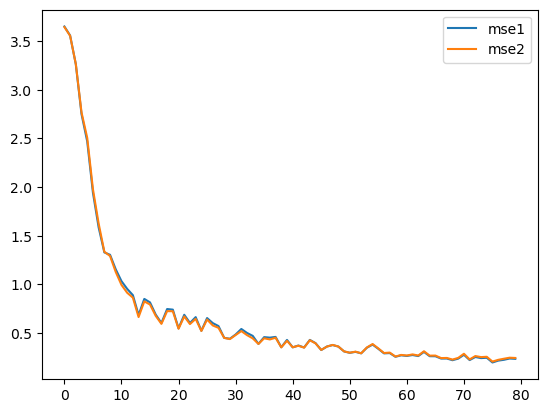

In [221]:
plt.plot(np.array(losses_1['mse'])[::4], label='mse1')
plt.plot(np.array(losses_2['mse'])[::4], label='mse2')
plt.legend()
plt.show()


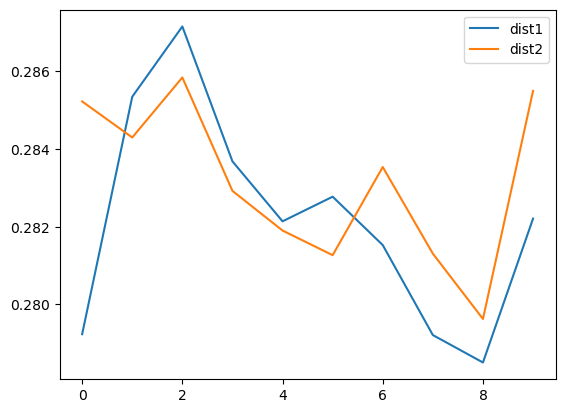

In [223]:
plt.plot(np.array(losses_1['distribution'])[-10:], label='dist1')
plt.plot(np.array(losses_2['distribution'])[-10:], label='dist2')
plt.legend()
plt.show()


In [201]:
import matplotlib.pyplot as plt

In [226]:
log_file = os.path.join(base_dir, "trial0.json")
with open(log_file, "r") as f:
    log_data = json.load(f)




In [229]:
log_data.keys()

dict_keys(['training_config', 'model_config', 'data_config', 'use_distribution_loss', 'use_diffusion_loss', 'mse_only_losses', 'dist_losses'])

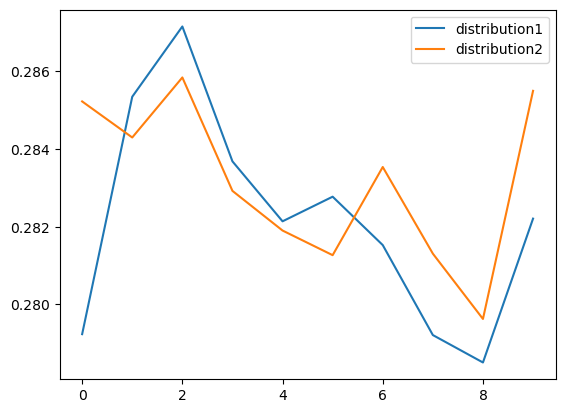

In [231]:
#plt.plot(losses_1['mse'], label='mse1')
plt.plot(log_data['mse_only_losses']['distribution'][-10:], label='distribution1')
#plt.plot(losses_2['mse'], label='mse2')
plt.plot(log_data['dist_losses']['distribution'][-10:], label='distribution2')
plt.legend()
plt.show()

In [98]:
trainer = tru.ClimsimTrainer(model, dataloaders, loss_fn, optimizer, 
                   tconfig, base_dir, use_distribution_loss, use_diffusion_loss, rank=0)

Initializing trainer with rank: 0
Using device: cuda:0


In [108]:
old_stderr = sys.stderr

In [ ]:
with open(os.path.join(trainer.dirs['output_dir'], f"{run_id}.txt"), "w") as f:
    print(f"Redirecting stderr to {f.name}")
    #stderr_fd = sys.stderr.fileno()
    #old_stderr = os.dup(stderr_fd)
    #os.dup2(f.fileno(), stderr_fd)
    sys.stderr = f
    trainer.train(num_epochs=10, log=True, run_id=run_id)


Redirecting stderr to /mnt/home/ssa2206/Climsim/experiments/JointTraining/outputs/trial0_just_mse.txt
Getting ready to train model for 10 epochs
Epoch 1/10
__________
Currently at epoch 0, step 0/64
Currently at epoch 0, step 10/64
Currently at epoch 0, step 20/64
Currently at epoch 0, step 30/64
Currently at epoch 0, step 40/64
epoch 0, step 49: saving checkpoint


# Diffusion Prior Loss

In [1]:
import torch
import torch.nn as nn

In [33]:
exp_id = "full_dataset_testrun"
base_dir = os.path.join("experiments", exp_id)
run_id = "trial_1b"
tconfig, mconfig, dconfig = tru.load_config(run_id, exp_id)


TrainLoaderParams(batch_size=256, shuffle=True, num_workers=8, prefetch_factor=4, persistent_workers=True, multiprocessing_context='forkserver', pin_memory=True)

In [7]:
ddpm = tru.load_model_from_ckpt(f"{run_id}-ckpt.pt", mconfig, exp_id).to(device)
mconfig.scheduler_type = "ddim"
scheduler = data.load_scheduler(mconfig)
scheduler.set_timesteps(num_inference_steps=mconfig.scheduler_inference_steps)
ddpm.device

device(type='cuda', index=0)

In [8]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [49]:
%%time
x, y = train_ds[0]

CPU times: user 505 ms, sys: 775 ms, total: 1.28 s
Wall time: 1.18 s


In [52]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [14]:
y_hat = model(x.to(device))

In [15]:
def construct_image(ytensor):
    # more complex in actual setup
    return(torch.transpose(ytensor, 1, 2).reshape(-1, 128, 16, 24))

In [103]:
loss_fn = nn.MSELoss()
def image_loss(y, yhat, T: int, unet=ddpm, scheduler=scheduler):
    y, yhat = construct_image(y), construct_image(yhat)
    def encode(sample):
        eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([T])) # noisy image
        return(xt)
    def decode(xt):
        for t in range(T, 0, -1):
            with torch.no_grad():
                eps_theta = unet(xt, t).sample
            xt = scheduler.step(eps_theta, t, xt).prev_sample
        return(xt)
    yhat = decode(encode(yhat))
    return(loss_fn(y, yhat))

In [54]:
image_loss(y.to(device), y_hat, 25)

tensor(1.4329, device='cuda:0', grad_fn=<MseLossBackward0>)

In [62]:
4204/256

16.421875

In [69]:
tconfig.num_epochs

20

In [72]:

len(test_ds)

8

In [80]:
%%time
c, d = train_ds[5]

CPU times: user 437 ms, sys: 1.85 ms, total: 438 ms
Wall time: 402 ms


In [81]:
%%time
loss_fn(model(a.to(device)), b.to(device))

CPU times: user 29.9 ms, sys: 0 ns, total: 29.9 ms
Wall time: 29.5 ms


tensor(0.9858, device='cuda:0', grad_fn=<MseLossBackward0>)

In [76]:
def evaluate_diff(model):
    loss = 0.0
    model.eval()
    with torch.no_grad():
        for idx in range(len(test_ds)):
            print(idx, end=" ")
            x, y = test_ds[idx]
            x, y = x.to(device), y.to(device)
            loss += loss_fn(model(x), y).item()
    return(loss / len(test_ds))

In [107]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [121]:
def diffusion_train(model, dataset, loss_fn, tconfig):
    optimizer = torch.optim.Adam(model.parameters(), lr=tconfig.learning_rate, weight_decay=1e-4)
    losses = dict(train=[], diffusion=[], test=[])
    for epoch in range(1, tconfig.num_epochs+1):
        model.train()  # Set the model to training mode
        pixel_loss, img_loss = 0.0, 0.0
        for idx in range(len(dataset)):
            print(idx, end=" ")
            x, y = dataset[idx]
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            ploss = loss_fn(y, y_hat)
            iloss = image_loss(y, y_hat, T=25)
            (ploss + iloss).backward()
            optimizer.step()
            pixel_loss += ploss.item(); img_loss += iloss.item()
            losses['train'].append(ploss.item()); losses['diffusion'].append(iloss.item());
        # Print training progress
        #average_loss = running_loss / len(dataloader)
        #test_loss = evaluate(model).item()
        print(f'\nEpoch [{epoch}/{tconfig.num_epochs}], Pixel Loss: {pixel_loss/len(dataset):.4f}, Image Loss: {img_loss/len(dataset):.4f}')
        
        if(epoch % tconfig.batch_checkpoint_interval == 0):
            print("Saving Model")
            torch.save(model.state_dict(), tconfig.ckpt_id)

    return(model, losses)

In [116]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [122]:
loss_fn(model(x.to(device)), y.to(device))

tensor(1.3941, device='cuda:0', grad_fn=<MseLossBackward0>)

In [123]:
x, y = train_ds[0]

In [127]:
model, losses = diffusion_train(model, train_ds, loss_fn, tconfig)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [1/10], Pixel Loss: 1.0640, Image Loss: 1.0884
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [2/10], Pixel Loss: 1.0268, Image Loss: 1.0556
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [3/10], Pixel Loss: 0.9956, Image Loss: 1.0274
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [4/10], Pixel Loss: 0.9671, Image Loss: 1.0011
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [5/10], Pixel Loss: 0.9403, Image Loss: 0.9758
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [6/10], Pixel Loss: 0.9146, Image Loss: 0.9515
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [7/10], Pixel Loss: 0.8901, Image Loss: 0.9280
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [8/10], Pixel Loss: 0.8668, Image Loss: 0.9055
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [9/10], Pixel Loss: 0.8446, Image Loss: 0.8840
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [10/10], Pixel Loss: 0.8236, Image Loss: 0.8637


In [130]:
torch.save(model.state_dict(), "experiments/JointTraining/diffusion_train.pt")

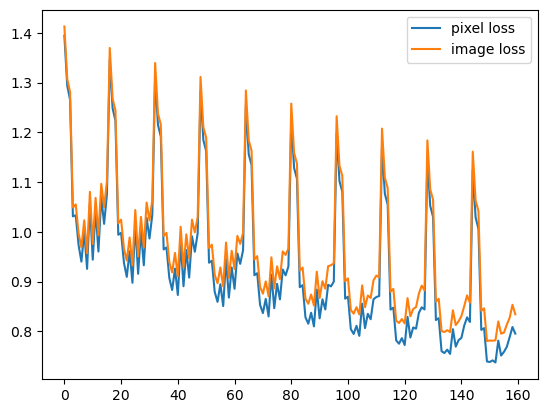

In [134]:
plt.plot(losses['train'], label='pixel loss')
plt.plot(losses['diffusion'], label='image loss')
plt.legend()
plt.show()

In [137]:
import json

In [139]:
with open("experiments/JointTraining/diffusion_train_losses.json", "w") as file:
    json.dump(losses, file)